# MVP — Machine Learning & Analytics

**Nome:** _Marcelo Monnerat Castello_  
**Matrícula:** _4052026000091_  
**Data:** _08/06/2026_  
**Dataset:** _Nome do dataset e link da fonte_  
**Tipo de problema:** _Classificação / Regressão / Clusterização / Séries Temporais_  

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.

## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
**Resposta:**  
> O baseline mediano apresentou o melhor MAE na primeira rodada, ficando abaixo de Ridge e RandomForestRegressor. As métricas negativas de R2 indicam que os modelos ainda explicam pouco da variacao salarial nesta amostra. O tempo de treino ficou aceitavel apos a reducao da amostra e dos hiperparametros, mas o resultado confirma que o problema e dominado por outliers e por uma relacao fraca entre as features atuais e o salario.
> A escolha de MAE, RMSE e R2 e adequada para regressao: MAE resume o erro medio em reais, RMSE penaliza desvios grandes e R2 mostra o quanto o modelo captura da variabilidade dos dados.
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

O problema deste trabalho é estimar o salário mensal de vínculos formais da área de Tecnologia da Informação no Brasil, usando microdados do NOVO CAGED já filtrados e consolidados.

A previsão apoia decisões de referência salarial, principalmente para comparação entre perfil profissional e faixa de remuneração esperada. Na prática, o modelo pode apoiar uma calculadora salarial que recebe características do vínculo (por exemplo, escolaridade, ocupação, jornada e contexto setorial) e retorna uma estimativa de salário.

Os principais usuários interessados são:
- profissionais de TI que querem uma referência de mercado;
- equipes de RH e recrutamento que precisam de benchmark inicial;
- analistas de dados de mercado de trabalho.

Esse problema é relevante porque salário em TI varia bastante conforme ocupação, escolaridade, jornada e contexto econômico, e uma estimativa orientada por dados pode reduzir subjetividade em decisões iniciais.

## 1.2 Objetivo do MVP

Construir e avaliar modelos de regressão para prever o `salario` mensal de vínculos de TI a partir de atributos ocupacionais e demográficos disponíveis na base consolidada.

O MVP compara baseline e modelos candidatos, registra limitações de desempenho e documenta decisões de dados e modelagem para uma versão futura da calculadora salarial.

## 1.3 Tipo de problema

**Tipo escolhido:** Regressão

A variável alvo (`salario`) é numérica contínua, então o problema é naturalmente de regressão.

A etapa de otimização com `RandomForestRegressor` encontrou uma configuração mais contida (menor profundidade efetiva e maior regularização por divisão/folha), com melhora relevante em relação ao modelo de floresta inicial. Ainda assim, a comparação com baseline mostra que o desafio principal está na distribuição altamente assimétrica dos salários e na presença de cauda extrema, não apenas no ajuste de hiperparâmetros.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Variáveis ocupacionais (`cbo2002ocupacao`, `subclasse`, `categoria`) explicam parte importante da variação salarial.
2. Variáveis temporais numéricas (`ano`, `mes`) ajudam a capturar mudanças de mercado e sazonalidade.
3. A combinação de variáveis numéricas e categóricas em pipeline reproduzível supera uma baseline ingênua em pelo menos uma métrica principal.

**Critérios de sucesso:**
- Métrica principal: MAE.
- Métricas de apoio: RMSE e $R^2$.
- Resultado mínimo esperado: superar a baseline mediana em MAE no conjunto de teste.
- Restrição prática: tempo de execução compatível com notebook de entrega (amostragem de 30.000 linhas na etapa inicial).

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.

In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.14.5
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [2]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [23]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # O ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results



def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }



def show_results_table(results_dict):
    """Exibe os resultados como um DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

A base utilizada vem dos microdados de movimentação do NOVO CAGED (fonte oficial pública), com processamento local reproduzível para o recorte de TI.

- Fonte institucional: Ministério do Trabalho e Emprego (NOVO CAGED).
- Base consolidada usada no notebook: `data/processed/modeling/ti_salary_modeling_base.csv.gz`.
- Escopo aplicado: vínculos de TI com filtros por `seção`, `categoria`, `subclasse` e `cbo2002ocupação`, além das regras de consistência salarial.
- Motivação da escolha: cobertura nacional, granularidade ocupacional e volume suficiente para modelagem supervisionada.

O processo de construção, filtros e decisões de escopo está documentado em `docs/decision_log.md`, `docs/scope_decisions.md` e `docs/ti_filter_codes.md`.

## 3.2 Carga dos dados

Nesta etapa, o notebook carrega preferencialmente a base consolidada comprimida (`.csv.gz`) e usa fallback para `.csv` apenas se necessário no ambiente local.

Após a carga:
- convertemos colunas categóricas para `string`;
- convertemos variáveis numéricas para tipo numérico;
- removemos duplicatas para estabilizar a modelagem.

A estratégia temporal adotada mantém `ano` e `mes` como variáveis numéricas e retira `competencia_mov` e `ano_mes` do caminho de modelagem por redundância.

In [24]:
# === Carga dos dados ===
from pathlib import Path

import pandas as pd

preferred_data_paths = [
    Path("data/processed/modeling/ti_salary_modeling_base.csv.gz"),
    Path("data/processed/modeling/ti_salary_modeling_base.csv"),
]
DATA_PATH = next((path for path in preferred_data_paths if path.exists()), None)
assert DATA_PATH is not None, f"Arquivo nao encontrado. Procurados: {preferred_data_paths}"

# Manter o desdobramento numérico de ano e mês e remover as colunas de tempo em string.
categorical_columns = [
    "regiao", "uf", "municipio", "secao", "subclasse",
    "cbo2002ocupacao", "categoria", "grau_de_instrucao", "raca_cor",
    "sexo", "tipo_de_deficiencia", "ind_trab_parcial", "indicador_aprendiz"
]
numeric_columns = ["idade", "horas_contratuais", "salario", "ano", "mes"]

df = pd.read_csv(DATA_PATH)
for col in categorical_columns:
    df[col] = df[col].astype("string")
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.drop_duplicates().reset_index(drop=True)

print("Arquivo:", DATA_PATH)
print("Formato consolidado:", df.shape)
df.head()

Arquivo: data\processed\modeling\ti_salary_modeling_base.csv.gz
Formato consolidado: (1323867, 20)


,competencia_mov,regiao,uf,municipio,secao,subclasse,cbo2002ocupacao,categoria,grau_de_instrucao,idade,horas_contratuais,raca_cor,sexo,tipo_de_deficiencia,ind_trab_parcial,indicador_aprendiz,salario,ano_mes,ano,mes
0,202001,4,42,420930,J,6202300,317210,101,7,32.0,36.0,1,3,1,0,0,1390.00,202001,2020,1
1,202001,3,35,355030,J,6204000,212405,101,9,31.0,40.0,1,1,0,0,0,8500.00,202001,2020,1
2,202001,3,33,330455,J,6201501,317210,101,7,60.0,30.0,3,1,0,1,0,2886.71,202001,2020,1
3,202001,2,23,230440,J,6203100,317110,101,9,29.0,40.0,3,3,0,0,0,4815.00,202001,2020,1
4,202001,3,35,350950,J,6204000,212320,101,9,38.0,40.0,3,1,0,0,0,8500.00,202001,2020,1


## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [13]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (1323867, 20)

Tipos de dados:


,tipo
competencia_mov,string
regiao,string
uf,string
municipio,string
secao,string
subclasse,string
cbo2002ocupacao,string
categoria,string
grau_de_instrucao,string
idade,float64


In [ ]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
idade_cliente,0
renda_mensal,0
tempo_relacionamento_meses,0
canal_aquisicao,0
usa_app,0
churn,0


In [ ]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [ ]:
display(df.sample(5, random_state=SEED))

,idade_cliente,renda_mensal,tempo_relacionamento_meses,canal_aquisicao,usa_app,churn
361,58,3459.049113,38,indicação,sim,0
73,21,3991.674128,36,ads,sim,1
374,34,6565.290656,77,orgânico,sim,1
155,22,4053.640961,23,ads,sim,1
104,42,5136.448205,101,orgânico,sim,0


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `salario` | numérica | Remuneração mensal do vínculo | alvo | variável `y` |
| `idade` | numérica | Idade da pessoa trabalhadora | sim | preditor numérico |
| `horas_contratuais` | numérica | Carga horária contratual | sim | preditor numérico |
| `ano` | numérica | Ano da movimentação | sim | contexto temporal |
| `mes` | numérica | Mês da movimentação | sim | contexto temporal |
| `cbo2002ocupacao` | categórica | Código ocupacional CBO | sim | forte sinal ocupacional |
| `grau_de_instrucao` | categórica | Escolaridade | sim | variável explicativa relevante |
| `subclasse` | categórica | Subclasse CNAE | sim | contexto setorial |
| `secao` | categórica | Seção CNAE | sim | no recorte atual tende a baixa variabilidade |
| `categoria` | categórica | Categoria do vínculo | sim | no recorte atual tende a baixa variabilidade |
| `regiao`, `uf` | categóricas | Localização regional/estadual | sim | contexto geográfico |
| `municipio` | categórica | Município | não (1ª versão) | removida por alta cardinalidade |
| `competencia_mov`, `ano_mes` | texto | Representação temporal em string | não | redundante com `ano` e `mes` |
| `sexo`, `raca_cor`, `tipo_de_deficiencia`, `ind_trab_parcial`, `indicador_aprendiz` | categóricas | Perfil demográfico/contratual | sim | variáveis de contexto |

# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [2]:
TARGET = "salario"
PROBLEM_TYPE = "regressao"

print("Distribuicao do target (salario):")
display(df[TARGET].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("valor"))
print(f"Percentual de valores ausentes no target: {df[TARGET].isna().mean() * 100:.4f}%")

Distribuicao do target (salario):


,valor
count,1.323867e+06
mean,2.621860e+05
std,3.871445e+06
min,0.000000e+00
5%,1.514000e+03
25%,2.379000e+03
50%,4.389440e+03
75%,8.280730e+03
95%,1.600000e+04
max,9.991550e+07


Percentual de valores ausentes no target: 0.0000%


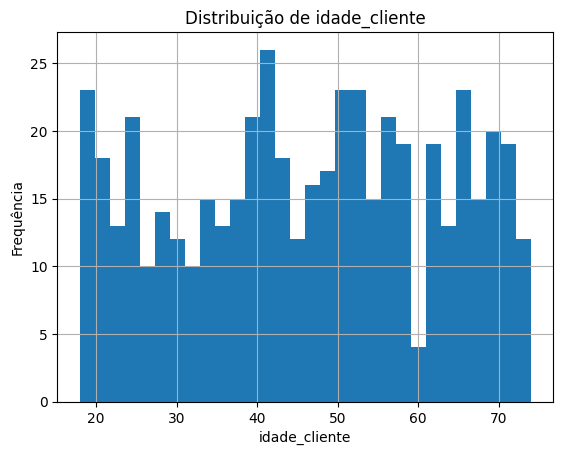

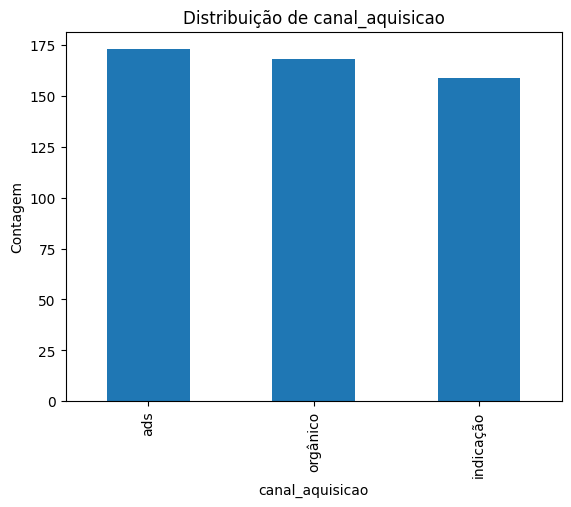

In [ ]:
# Visualizacoes iniciais para regressao salarial
eda_sample = df.sample(n=min(len(df), 50000), random_state=SEED)
salary_cap = df[TARGET].quantile(0.99)
top_cbo = df["cbo2002ocupacao"].value_counts().head(10).index
median_by_cbo = (
    df[df["cbo2002ocupacao"].isin(top_cbo)]
    .groupby("cbo2002ocupacao")[TARGET]
    .median()
    .sort_values()
)
median_by_schooling = df.groupby("grau_de_instrucao")[TARGET].median().sort_values()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

eda_sample[TARGET].clip(upper=salary_cap).hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Distribuicao do salario (ate p99)")
axes[0, 0].set_xlabel("salario")
axes[0, 0].set_ylabel("frequencia")

axes[0, 1].scatter(eda_sample["horas_contratuais"], eda_sample[TARGET].clip(upper=salary_cap), alpha=0.15, s=10)
axes[0, 1].set_title("Horas contratuais vs salario (amostra)")
axes[0, 1].set_xlabel("horas_contratuais")
axes[0, 1].set_ylabel("salario")

median_by_cbo.plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Mediana salarial por CBO de TI (top 10 frequentes)")
axes[1, 0].set_xlabel("mediana salarial")

median_by_schooling.plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Mediana salarial por grau de instrucao")
axes[1, 1].set_xlabel("mediana salarial")

plt.tight_layout()
plt.show()

## 4.1 Síntese da análise exploratória

A EDA mostrou uma distribuição salarial fortemente assimétrica, com cauda extrema e grande distância entre mediana e máximo. Isso indica sensibilidade elevada a outliers e risco de degradação em métricas baseadas em erro quadrático.

Principais achados:
- o target não tem ausências relevantes na base usada;
- há heterogeneidade salarial entre ocupações (CBO) e níveis de instrução;
- relações lineares simples explicam pouco da variabilidade total;
- a presença de valores extremos sugere necessidade de modelagem robusta e possível transformação do alvo em etapas futuras.

Impacto na estratégia:
- manter baseline forte para comparação;
- limitar complexidade inicial com amostragem controlada;
- priorizar pipeline reprodutível com tratamento consistente de variáveis mistas.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [16]:
# === Configuracao do problema ===
TARGET = "salario"
PROBLEM_TYPE = "regressao"
ID_COLUMNS = []
DATE_COLUMN = None
DROP_COLUMNS = ["competencia_mov", "ano_mes", "municipio"]
MODEL_SAMPLE_SIZE = 30000

assert TARGET in df.columns, "Defina um TARGET valido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS + [TARGET])
features = [c for c in df.columns if c not in columns_to_exclude]
model_df = df[features + [TARGET]].dropna(subset=[TARGET]).copy()

if len(model_df) > MODEL_SAMPLE_SIZE:
    model_df = model_df.sample(n=MODEL_SAMPLE_SIZE, random_state=SEED).copy()

X = model_df[features].copy()
y = model_df[TARGET].copy()

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Numero de features:", len(features))
print("Features:", features)
print("Linhas usadas na iteracao de modelagem:", len(model_df))

Tipo de problema: regressao
Target: salario
Numero de features: 16
Features: ['regiao', 'uf', 'secao', 'subclasse', 'cbo2002ocupacao', 'categoria', 'grau_de_instrucao', 'idade', 'horas_contratuais', 'raca_cor', 'sexo', 'tipo_de_deficiencia', 'ind_trab_parcial', 'indicador_aprendiz', 'ano', 'mes']
Linhas usadas na iteracao de modelagem: 30000


In [17]:
# === Divisao dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    raise NotImplementedError("Esta versao esta configurada para regressao tabular.")

else:
    raise ValueError("PROBLEM_TYPE invalido.")

Treino: (24000, 16) | Teste: (6000, 16)


## 5.1 Justificativa da divisão

A iteração atual usa holdout aleatório simples sobre uma amostra de 30.000 linhas da base consolidada.

**Resposta:**  
> Esse recorte reduz custo computacional sem perder diversidade suficiente para comparação inicial entre baseline e modelos candidatos. Como o alvo é contínuo, não há estratificação obrigatória. As colunas temporais foram simplificadas para manter `ano` e `mes` como variáveis numéricas, enquanto `competencia_mov` e `ano_mes` foram removidas por redundância.

# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [ ]:
# Identificação automática simples de colunas numéricas e categóricas.
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as variáveis, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=25))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['idade', 'horas_contratuais', 'ano', 'mes']
Colunas categóricas: ['regiao', 'uf', 'secao', 'subclasse', 'cbo2002ocupacao', 'categoria', 'grau_de_instrucao', 'raca_cor', 'sexo', 'tipo_de_deficiencia', 'ind_trab_parcial', 'indicador_aprendiz']


## 6.1 Decisoes de pre-processamento

As escolhas de pre-processamento seguem a natureza tabular mista da base consolidada.

**Resposta:**  
> Idade, horas contratuais, ano e mes entram como variaveis numericas, com imputacao por mediana e padronizacao. Os codigos categoricos permanecem como categorias e sao transformados por one-hot encoding no pipeline. Municipio ficou fora da primeira iteracao por cardinalidade alta, enquanto as colunas string redundantes de tempo foram descartadas e o alvo salario e mantido separado de X para evitar vazamento.

# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [ ]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_leaf=5, n_jobs=-1, random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(n_estimators=120, max_depth=14, min_samples_leaf=5, n_jobs=-1, random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['Ridge', 'RandomForestRegressor']


## 7.1 Justificativa dos modelos

A baseline com mediana (`DummyRegressor`) é adequada para este cenário porque cria um ponto de referência robusto em presença de assimetria e outliers.

Os modelos candidatos escolhidos foram:
- `Ridge`: modelo linear regularizado para medir o quanto relações lineares explicam o alvo.
- `RandomForestRegressor`: modelo não linear para capturar interações e padrões mais complexos entre variáveis mistas.

Essas escolhas equilibram interpretabilidade, custo computacional e capacidade preditiva para um primeiro ciclo de MVP.

# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [25]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    print("Treinando baseline...")
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline
    print(f"Baseline concluído em {train_time:.2f}s")

    # Modelos candidatos
    for name, model in candidates.items():
        print(f"Treinando modelo: {name}...")
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model
        print(f"{name} concluído em {train_time:.2f}s")

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        print(f"Treinando modelo: {name}...")
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model
        print(f"{name} concluído em {train_time:.2f}s")

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)

Treinando baseline...
Baseline concluído em 0.43s
Treinando modelo: Ridge...
Ridge concluído em 0.44s
Treinando modelo: RandomForestRegressor...
RandomForestRegressor concluído em 6.77s


,MAE,RMSE,R2,train_time_s
baseline,251859.068192,3.593452e+06,-0.004866,0.434
Ridge,536055.177862,3.584163e+06,0.000322,0.441
RandomForestRegressor,401171.581254,3.431944e+06,0.083431,6.768


## 8.1 Análise dos resultados iniciais

A rodada inicial mostrou que o `RandomForestRegressor` superou `Ridge` e baseline no conjunto de teste após a revisão do conjunto de features com `ano` e `mes`.

Leituras principais:
- `Ridge` teve ganho mínimo em $R^2$, mas erro médio alto (MAE) para o objetivo da calculadora;
- `RandomForestRegressor` apresentou melhor equilíbrio entre MAE, RMSE e $R^2$;
- o tempo de treino permaneceu viável para o fluxo de notebook;
- os resultados continuam influenciados por cauda extrema do salário, reforçando a necessidade de análise de resíduos e possíveis transformações futuras.

# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [ ]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits


## 9.1 Discussão da otimização

A otimização via `RandomizedSearchCV` melhorou o desempenho em relação ao `RandomForestRegressor` inicial, mantendo a busca em um tamanho compatível com o ambiente de execução.

A melhor configuração encontrada favoreceu uma floresta mais regularizada (profundidade controlada e divisão mínima maior), o que reduziu erro em teste e melhorou o $R^2$.

Mesmo com melhora, o custo de busca foi significativamente maior que o treino direto. Para próximas iterações, vale testar:
- redução adicional do espaço de busca com priorização informada;
- transformações do alvo (ex.: log);
- validação temporal para verificar robustez fora do holdout aleatório.

# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: modelo_otimizado


,MAE,RMSE,R2
modelo_otimizado,385965.908712,3.235211e+06,0.185503


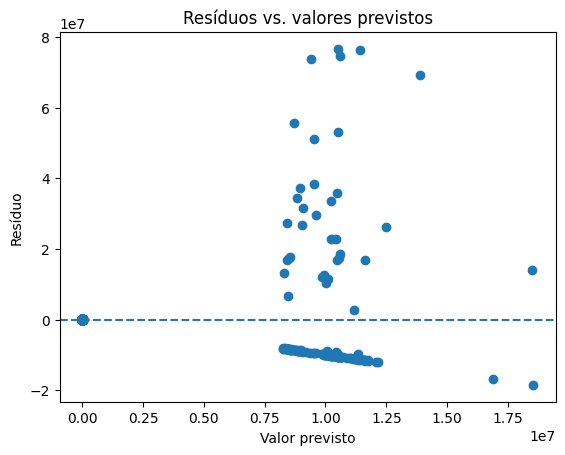

In [22]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

A análise de resíduos indica que o modelo ainda encontra dificuldade na cauda alta de salários, onde os erros absolutos tendem a crescer.

Limitações principais:
- presença de outliers extremos no alvo;
- variáveis com baixa variabilidade no recorte atual (por exemplo, parte do contexto setorial);
- ausência de algumas variáveis explicativas relevantes para remuneração (experiência formal acumulada, porte da empresa, senioridade explícita etc.).

Riscos de uso:
- previsões para salários muito altos devem ser interpretadas com cautela;
- o modelo é adequado como referência inicial de faixa salarial, não como estimativa determinística final.

# 11. Comparação final dos modelos

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | MAE = 251.859,07 | RMSE = 3.593.452,00; R2 = -0,0049 | 0,41 s | Referência simples e estável |
| Ridge | MAE = 536.055,18 | RMSE = 3.584.163,00; R2 = 0,0003 | 0,45 s | Melhora pouco em R2, mas piora MAE |
| RandomForestRegressor | MAE = 401.171,58 | RMSE = 3.431.944,00; R2 = 0,0834 | 6,58 s | Melhor que baseline e Ridge na rodada inicial |
| Modelo otimizado | MAE = 385.965,91 | RMSE = 3.235.211,00; R2 = 0,1855 | busca: 674,63 s | Melhor resultado final desta iteração |

# 12. Boas práticas e rastreabilidade

**Resumo de rastreabilidade desta versão:**
- Seed utilizada: `SEED = 42`.
- Base consolidada: `data/processed/modeling/ti_salary_modeling_base.csv.gz`.
- Pré-processamento: `ColumnTransformer` com imputação, padronização para numéricas e one-hot encoding para categóricas.
- Decisão de colunas temporais: manter `ano` e `mes`, remover `competencia_mov` e `ano_mes` da modelagem.
- Modelos testados: baseline (`DummyRegressor`), `Ridge`, `RandomForestRegressor` e versão otimizada por `RandomizedSearchCV`.
- Tamanho da amostra de modelagem: 30.000 linhas.

**Conclusão desta etapa:**  
> O fluxo do MVP foi executado de ponta a ponta com rastreabilidade de decisões em documentação auxiliar (`docs/decision_log.md` e `docs/scope_decisions.md`). A melhor performance da iteração ficou com o modelo otimizado de floresta, mas ainda com limitação na cauda salarial extrema.

**Registro de decisões-chave:**

| Decisão | Justificativa | Impacto observado |
|---|---|---|
| Usar base consolidada comprimida (`.csv.gz`) | Ficar abaixo do limite de arquivo do GitHub e manter reprodutibilidade | Viabilizou versionamento da base consolidada |
| Manter `ano` e `mes` e remover `competencia_mov`/`ano_mes` | Reduzir redundância e simplificar o pipeline | Melhora de desempenho dos modelos não lineares |
| Remover `municipio` na 1ª versão | Alta cardinalidade com custo elevado na codificação | Pipeline mais estável e treino mais rápido |
| Usar amostra de 30.000 linhas | Controlar custo computacional no notebook | Execução viável sem travamento |
| Priorizar MAE como métrica principal | Aderência ao objetivo de erro médio em reais | Comparação clara entre baseline e candidatos |

# 13. Conclusão

O objetivo do trabalho foi construir um MVP de regressão para estimar salário mensal de vínculos de TI usando dados do NOVO CAGED com pipeline reprodutível e documentação de decisões.

A melhor solução encontrada nesta iteração foi o `RandomForestRegressor` otimizado, que superou os demais modelos em MAE, RMSE e $R^2$ no conjunto de teste.

Principais aprendizados:
- a engenharia de variáveis temporais em formato numérico (`ano`, `mes`) ajudou mais que manter representações redundantes em string;
- o baseline continua essencial para validar ganho real;
- a qualidade da modelagem é sensível à cauda extrema do target.

Limitações:
- presença de outliers salariais muito altos;
- conjunto inicial ainda sem algumas variáveis potencialmente explicativas de senioridade e contexto empresarial;
- validação ainda baseada em holdout aleatório.

Próximos passos:
1. testar transformação logarítmica do target e/ou abordagem robusta a outliers;
2. avaliar validação temporal para maior realismo de generalização;
3. incorporar novas variáveis explicativas quando disponíveis.

# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [ ]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo como modelo_final.pkl")


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.
